# Stage 2: Out-of-Sample PCA Early Warning

## Setup and Imports


In [1]:
#%pip install pandas pyarrow
import os
import pandas as pd
import pyarrow.parquet as pq

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [2]:
# load in all stablecoins
dai = pd.read_parquet("clean_data/dai_clean.parquet")
pax = pd.read_parquet("clean_data/pax_clean.parquet")
usdc = pd.read_parquet("clean_data/usdc_clean.parquet")
usdt = pd.read_parquet("clean_data/usdt_clean.parquet")
ust = pd.read_parquet("clean_data/ust_clean.parquet")

In [3]:
print("DAI:", dai["depeg"].sum())
print("USDC:", usdc["depeg"].sum())
print("USDT:", usdt["depeg"].sum())
print("USDP:", pax["depeg"].sum())

ust_cut = ust[ust["timestamp"] <= "2022-05-11"]
print("UST:", ust_cut["depeg"].sum())

DAI: 32
USDC: 32
USDT: 29
USDP: 35
UST: 33


### Identifying Optimal Train/Test Split
We define a function below to help identify the optimal split for each stablecoin such that the number of depegs in each split is approximately equal.

In [4]:
def split_equal_depegs(df, date_col="timestamp", target_col="depeg"):
    
    df = df.sort_values(date_col).reset_index(drop=True)
    df = df[df["timestamp"] <= "2024-12-31"]

    # cumulative number of depegs
    cumsum = df[target_col].cumsum()
    total = cumsum.iloc[-1]

    # find split where half depegs in each
    split_idx = (cumsum - total/2).abs().idxmin()

    train = df.iloc[:split_idx+1].copy()
    test  = df.iloc[split_idx+1:].copy()

    print("Split date:", df.loc[split_idx, date_col])
    print("Train depegs:", train[target_col].sum())
    print("Test  depegs:", test[target_col].sum())
    print("Train size:", len(train), "Test size:", len(test))
    print("------")

    return train, test

In [5]:
splits = {}
for name, df in {"DAI": dai, "USDC": usdc, "USDT": usdt, "USDP": pax, "UST": ust_cut}.items():
    print(name)
    train, test = split_equal_depegs(df)
    splits[name] = (train, test)

DAI
Split date: 2021-04-04 23:59:59
Train depegs: 16
Test  depegs: 16
Train size: 131 Test size: 1366
------
USDC
Split date: 2021-06-12 23:59:59
Train depegs: 16
Test  depegs: 16
Train size: 200 Test size: 1297
------
USDT
Split date: 2022-05-12 23:59:59
Train depegs: 13
Test  depegs: 14
Train size: 534 Test size: 963
------
USDP
Split date: 2023-07-25 23:59:59
Train depegs: 17
Test  depegs: 18
Train size: 973 Test size: 524
------
UST
Split date: 2021-02-06 23:59:59
Train depegs: 16
Test  depegs: 17
Train size: 74 Test size: 458
------


Given the rarity of depegging events, a purely chronological split may result in an insufficient number of events in the test set, limiting the reliability of early-warning evaluation.

To address this, we adopt an event-balanced split, ensuring comparable numbers of depegs in training and testing samples.

**The visual analysis reinforces the quantitative results under the equal-depeg split. For TerraUSD, warning signals are relatively sparse and tend to cluster in the periods leading up to depegging events, suggesting that abnormal movements in the selected latent factors capture meaningful instability. In contrast, for fiat-backed stablecoins such as USDC, DAI, and USDT, signals appear almost continuously throughout the test period. This indicates that the model is reacting less to event-specific stress and more to persistent deviations from the training baseline, which substantially reduces its usefulness as an early-warning system for these assets.**

**One possible explanation is that the fixed training benchmark may be poorly suited to fiat-backed stablecoins when the test period differs materially from the training regime. In other words, the weak performance may reflect structural breaks between train and test samples rather than purely poor factor selection. This motivates a further robustness exercise using a global calendar split, which allows us to assess whether the results are sensitive to the event-balanced splitting rule.**

In [6]:
# function that allows us to split the dataset on a specific date

def split_by_date(df, split_date, date_col="timestamp"):
    df = df.sort_values(date_col).reset_index(drop=True)
    df = df[df[date_col] <= "2024-12-31"]
    train = df[df[date_col] <= split_date].copy()
    test  = df[df[date_col] >  split_date].copy()
    print(f"Split date: {split_date}")
    print(f"Train depegs: {train['depeg'].sum()}, Test depegs: {test['depeg'].sum()}")
    print(f"Train size: {len(train)}, Test size: {len(test)}")
    print("------")
    return train, test

#### Global Split

In [7]:
global_split_date = "2021-10-01"
splits = {}
for name, df in {"DAI": dai, "USDC": usdc, "USDT": usdt, "USDP": pax, "UST": ust_cut}.items():
    print(name)
    train, test = split_by_date(df, global_split_date)
    splits[name] = (train, test)

DAI
Split date: 2021-10-01
Train depegs: 18, Test depegs: 14
Train size: 310, Test size: 1187
------
USDC
Split date: 2021-10-01
Train depegs: 19, Test depegs: 13
Train size: 310, Test size: 1187
------
USDT
Split date: 2021-10-01
Train depegs: 11, Test depegs: 16
Train size: 310, Test size: 1187
------
USDP
Split date: 2021-10-01
Train depegs: 4, Test depegs: 31
Train size: 310, Test size: 1187
------
UST
Split date: 2021-10-01
Train depegs: 25, Test depegs: 8
Train size: 310, Test size: 222
------


### Summary Table

In [8]:
summary = []

for k,(tr,te) in splits.items():
    summary.append({
        "coin": k,
        "train_start": tr.timestamp.min(),
        "train_end": tr.timestamp.max(),
        "test_start": te.timestamp.min(),
        "test_end": te.timestamp.max(),
        "train_depegs": tr.depeg.sum(),
        "test_depegs": te.depeg.sum()
    })

pd.DataFrame(summary)

,coin,train_start,train_end,test_start,test_end,train_depegs,test_depegs
0,DAI,2020-11-25 23:59:59,2021-09-30 23:59:59,2021-10-01 23:59:59,2024-12-30 23:59:59,18,14
1,USDC,2020-11-25 23:59:59,2021-09-30 23:59:59,2021-10-01 23:59:59,2024-12-30 23:59:59,19,13
2,USDT,2020-11-25 23:59:59,2021-09-30 23:59:59,2021-10-01 23:59:59,2024-12-30 23:59:59,11,16
3,USDP,2020-11-25 23:59:59,2021-09-30 23:59:59,2021-10-01 23:59:59,2024-12-30 23:59:59,4,31
4,UST,2020-11-25 23:59:59,2021-09-30 23:59:59,2021-10-01 23:59:59,2022-05-10 23:59:59,25,8


## PCA Framework

In [9]:
df_dai_final = pd.read_parquet("clean_data/dai_final.parquet")
df_pax_final = pd.read_parquet("clean_data/pax_final.parquet")
df_usdc_final = pd.read_parquet("clean_data/usdc_final.parquet")
df_usdt_final = pd.read_parquet("clean_data/usdt_final.parquet")
df_ust_final = pd.read_parquet("clean_data/ust_final.parquet")
# only use ust data up till may 2022
df_ust_final = df_ust_final[df_ust_final["timestamp"] <= "2022-05-11"]

In [10]:
# prepare PCA input
def prepare_stablecoin_pca_df(df):

    drop_cols = [
        'depeg', 'timeOpen', 'timeClose', 'timeHigh', 'timeLow',
        'open', 'high', 'low', 'close', 'volume', 'marketCap', 'circulatingSupply',
        'depeg_future_1d', 'depeg_future_3d', 'depeg_future_5d', 'depeg_future_7d', 
        'depeg_future_14d', 'depeg_future_30d'
    ]

    pca_df = df.copy()

    # drop only columns that actually exist
    pca_df = pca_df.drop(columns=[c for c in drop_cols if c in pca_df.columns], errors="ignore")
    
    pca_df['timestamp'] = pd.to_datetime(pca_df['timestamp']).dt.normalize()
    # keep only timestamp, symbol and numeric feature columns
    pca_df = pca_df[['timestamp', 'symbol'] + [c for c in pca_df.columns if c not in ['timestamp', 'symbol'] and pd.api.types.is_numeric_dtype(pca_df[c])]]

    # sort by time
    pca_df = pca_df.sort_values('timestamp').reset_index(drop=True)
    
    return pca_df

### Split Each Stablecoin into Train/Test

In [11]:
# split by global date and prepare PCA input
global_split_date = "2021-10-01"

dai_train, dai_test = split_by_date(df_dai_final, global_split_date)
dai_train_pca = prepare_stablecoin_pca_df(dai_train)
dai_test_pca = prepare_stablecoin_pca_df(dai_test)

pax_train, pax_test = split_by_date(df_pax_final, global_split_date)
pax_train_pca = prepare_stablecoin_pca_df(pax_train)
pax_test_pca = prepare_stablecoin_pca_df(pax_test)

usdc_train, usdc_test = split_by_date(df_usdc_final, global_split_date)
usdc_train_pca = prepare_stablecoin_pca_df(usdc_train)
usdc_test_pca = prepare_stablecoin_pca_df(usdc_test)

usdt_train, usdt_test = split_by_date(df_usdt_final, global_split_date)
usdt_train_pca = prepare_stablecoin_pca_df(usdt_train)
usdt_test_pca = prepare_stablecoin_pca_df(usdt_test)

ust_train, ust_test = split_by_date(df_ust_final, global_split_date)
ust_train_pca = prepare_stablecoin_pca_df(ust_train)
ust_test_pca = prepare_stablecoin_pca_df(ust_test)

Split date: 2021-10-01
Train depegs: 9, Test depegs: 14
Train size: 280, Test size: 1187
------
Split date: 2021-10-01
Train depegs: 4, Test depegs: 31
Train size: 280, Test size: 1187
------
Split date: 2021-10-01
Train depegs: 19, Test depegs: 13
Train size: 280, Test size: 1187
------
Split date: 2021-10-01
Train depegs: 10, Test depegs: 16
Train size: 280, Test size: 1187
------
Split date: 2021-10-01
Train depegs: 25, Test depegs: 8
Train size: 280, Test size: 222
------


### Run PCA

In [12]:
# run PCA
def fit_fixed_pca(train_df, test_df, n_components):
    numeric_cols = [c for c in train_df.columns if c not in ["timestamp", "symbol"]]

    # imputer: fill NaNs with training mean
    imputer = SimpleImputer(strategy="mean")
    X_train_imputed = imputer.fit_transform(train_df[numeric_cols])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    
    pca = PCA(n_components=n_components)
    X_train_pcs = pca.fit_transform(X_train_scaled)
    
    # train results
    train_pcs = pd.DataFrame(X_train_pcs, columns=[f"PC{i+1}" for i in range(X_train_pcs.shape[1])], index=train_df.index)
    
    # test projection
    X_test_imputed = imputer.transform(test_df[numeric_cols])
    X_test_scaled = scaler.transform(X_test_imputed)
    test_pcs = pd.DataFrame(pca.transform(X_test_scaled), columns=train_pcs.columns, index=test_df.index)
    
    return {
        "loadings": pd.DataFrame(pca.components_.T, index=numeric_cols),
        "explained_variance": pca.explained_variance_ratio_,
        "pc_scores_train": train_pcs,
        "pc_scores_test": test_pcs
    }

In [13]:
# DAI
dai_pca_result = fit_fixed_pca(dai_train_pca, dai_test_pca, n_components=10)

# USDC
usdc_pca_result = fit_fixed_pca(usdc_train_pca, usdc_test_pca, n_components=10)

# UST
ust_pca_result = fit_fixed_pca(ust_train_pca, ust_test_pca, n_components=10)

# USDT
usdt_pca_result = fit_fixed_pca(usdt_train_pca, usdt_test_pca, n_components=10)

# USDP (PAX)
pax_pca_result = fit_fixed_pca(pax_train_pca, pax_test_pca, n_components=10)

In [14]:
os.makedirs("stage2_pca_results/globaldate", exist_ok=True)

for coin, res in [
    ("UST", ust_pca_result),
    ("USDC", usdc_pca_result),
    ("DAI", dai_pca_result),
    ("USDT", usdt_pca_result),
    ("USDP", pax_pca_result),
]:
    base = f"stage2_pca_results/globaldate/{coin}"
    
    # 1. loadings (DataFrame → CSV)
    res["loadings"].to_csv(f"{base}_loadings.csv")
    
    # 2. explained variance (array → CSV)
    pd.DataFrame(res["explained_variance"]).to_csv(f"{base}_explained_variance.csv", index=False)
    
    # 3. PC scores (arrays → CSV)
    pd.DataFrame(res["pc_scores_train"]).to_csv(f"{base}_pc_train.csv", index=False)
    pd.DataFrame(res["pc_scores_test"]).to_csv(f"{base}_pc_test.csv", index=False)

### PC Selection

In [15]:
# set these based on f1 scores 
# UST: pc10, pc6, pc4
# USDC: pc9, pc6, pc3
# USDP: pc5, pc3, pc1
# USDT: pc5, pc1, pc8
# DAI: pc5, pc4, pc10
PC_SELECTIONS = {
    "UST":  [9, 5, 3], 
    "USDC": [8, 5, 2],   
    "USDP": [4, 2, 0],
    "USDT": [4, 0, 7],
    "DAI":  [4, 3, 9],
}

# compute mean and SD of selected PC scores on the training set
def compute_training_benchmark(pca_result, selected_pcs):
    train_scores = pca_result["pc_scores_train"]
    pc_cols = [f"PC{i+1}" for i in selected_pcs]
    mu    = train_scores[pc_cols].mean()
    sigma = train_scores[pc_cols].std(ddof=1)
    print("Training benchmark distribution:")
    for col in pc_cols:
        print(f"  {col}: mean={mu[col]:.4f}, sd={sigma[col]:.4f}")
    return {"mu": mu, "sigma": sigma, "pc_cols": pc_cols}

### Test Z-Scores and Anomaly Signal

In [16]:
# project test PC scores into the training distribution → z-scores
def compute_test_zscores(pca_result, benchmark):
    test_scores = pca_result["pc_scores_test"][benchmark["pc_cols"]]
    z_scores = (test_scores - benchmark["mu"]) / benchmark["sigma"]
    z_scores.columns = [f"z_{c}" for c in benchmark["pc_cols"]]
    return z_scores

# binary signal: 1 if ANY monitored PC exceeds ±threshold
# consecutive_days > 1 requires that many consecutive triggers (noise filter)
def generate_signal(z_scores, threshold=3.0, consecutive_days=1):
    any_exceed = (z_scores.abs() > threshold).any(axis=1).astype(int)
    if consecutive_days <= 1:
        return any_exceed
    rolling_sum = any_exceed.rolling(window=consecutive_days, min_periods=consecutive_days).sum()
    return (rolling_sum >= consecutive_days).astype(int)

### Warning Labels

In [17]:
# label each test day 1 if it falls within `window_days` before a depeg
# (exclusive of the depeg day itself)
# also records lead_days to next depeg
    
def build_warning_labels(test_df, signal, window_days=7,
                         date_col="timestamp", depeg_col="depeg"):
    df = test_df[[date_col, depeg_col]].copy().reset_index(drop=True)
    df["date"]   = pd.to_datetime(df[date_col]).dt.normalize()
    df["signal"] = signal.values
    df["depeg"]  = df[depeg_col].values

    depeg_dates = df.loc[df["depeg"] == 1, "date"].values

    def min_lead(d):
        future = depeg_dates[depeg_dates >= d]
        return (future[0] - d) / np.timedelta64(1, "D") if len(future) > 0 else np.nan

    df["lead_days"] = df["date"].apply(min_lead)
    df["label"]     = ((df["lead_days"] > 0) & (df["lead_days"] <= window_days)).astype(int)
    return df[["date", "signal", "depeg", "label", "lead_days"]]

### Predictive Metrics

In [18]:
# precision (key), recall, F1, specificity, avg lead time, false alarms/month
def compute_metrics(labeled_df, coin=""):
    y_true = labeled_df["label"].values
    y_pred = labeled_df["signal"].values

    TP = int(((y_pred == 1) & (y_true == 1)).sum())
    FP = int(((y_pred == 1) & (y_true == 0)).sum())
    TN = int(((y_pred == 0) & (y_true == 0)).sum())
    FN = int(((y_pred == 0) & (y_true == 1)).sum())

    precision   = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall      = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1          = (2 * precision * recall / (precision + recall)
                   if not (np.isnan(precision) or np.isnan(recall) or (precision + recall) == 0)
                   else np.nan)
    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan

    tp_mask      = (y_pred == 1) & (y_true == 1)
    avg_lead     = labeled_df.loc[tp_mask, "lead_days"].dropna().mean()
    fa_per_month = FP / (len(labeled_df) / 30.44)

    print(f"\n{'='*50}")
    print(f"  {coin} — Predictive Metrics")
    print(f"{'='*50}")
    print(f"  Confusion: TP={TP}, FP={FP}, TN={TN}, FN={FN}")
    print(f"  Precision  (key): {precision:.3f}")
    print(f"  Recall:           {recall:.3f}")
    print(f"  F1:               {f1:.3f}")
    print(f"  Specificity:      {specificity:.3f}")
    print(f"  Avg lead time:    {avg_lead:.1f} days before depeg")
    print(f"  False alarms:     {fa_per_month:.2f} / month")

    return {
        "coin": coin,
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "specificity": round(specificity, 4),
        "avg_lead_days": round(avg_lead, 2) if not np.isnan(avg_lead) else np.nan,
        "fa_per_month": round(fa_per_month, 2),
        "n_test_days": len(labeled_df),
    }

### Run Out-of-Sample Evaluation

In [19]:
def run_oos_evaluation(coin, pca_result, test_df, selected_pcs=None,
                       threshold=3.0, consecutive_days=1, window_days=7):
    if selected_pcs is None:
        selected_pcs = PC_SELECTIONS.get(coin, [0])

    # combined signal across all selected PCs
    benchmark  = compute_training_benchmark(pca_result, selected_pcs)
    z_scores   = compute_test_zscores(pca_result, benchmark)
    signal     = generate_signal(z_scores, threshold=threshold, consecutive_days=consecutive_days)
    labeled_df = build_warning_labels(test_df, signal, window_days=window_days)
    metrics    = compute_metrics(labeled_df, coin=coin)

    # per-PC breakdown
    pc_rows = []
    for pc_idx in selected_pcs:
        bm   = compute_training_benchmark(pca_result, [pc_idx])
        z    = compute_test_zscores(pca_result, bm)
        sig  = generate_signal(z, threshold=threshold, consecutive_days=consecutive_days)
        ldf  = build_warning_labels(test_df, sig, window_days=window_days)
        m    = compute_metrics(ldf, coin=f"{coin} PC{pc_idx+1}")
        m["pc"] = f"PC{pc_idx+1}"
        pc_rows.append(m)
    pc_breakdown = pd.DataFrame(pc_rows)[["pc","precision","recall","f1","specificity","avg_lead_days","fa_per_month","TP","FP","TN","FN"]]

    return {"metrics": metrics, "labeled_df": labeled_df,
            "z_scores": z_scores, "benchmark": benchmark, "signal": signal,
            "pc_breakdown": pc_breakdown}

In [20]:
def sensitivity_sweep(coin, pca_result, test_df, selected_pcs,
                      thresholds=[1.5, 2.0, 2.5, 3.0],
                      windows=[5, 7, 10], consecutive_days=1):
    rows = []
    for thr in thresholds:
        for win in windows:
            bm  = compute_training_benchmark(pca_result, selected_pcs)
            z   = compute_test_zscores(pca_result, bm)
            sig = generate_signal(z, threshold=thr, consecutive_days=consecutive_days)
            ldf = build_warning_labels(test_df, sig, window_days=win)
            m   = compute_metrics(ldf, coin=coin)
            m["threshold"] = thr; m["window"] = win
            rows.append(m)
    cols = ["coin","threshold","window","precision","recall","f1",
            "specificity","avg_lead_days","fa_per_month","TP","FP","TN","FN"]
    return pd.DataFrame(rows)[cols].sort_values(["precision","recall"], ascending=False)

### Plot Z-Score Timeline with Depeg Markers and Warning Windows

In [21]:
def plot_signal_timeline(result, coin, threshold=3.0, figsize=(14, 4), save_path=None):
    labeled_df = result["labeled_df"]
    z_scores   = result["z_scores"]
    dates      = labeled_df["date"].values

    fig, axes = plt.subplots(len(z_scores.columns), 1, figsize=figsize, sharex=True)
    if len(z_scores.columns) == 1:
        axes = [axes]

    signal_dates = labeled_df.loc[labeled_df["signal"] == 1, "date"].values

    for ax, col in zip(axes, z_scores.columns):
        ax.plot(dates, z_scores[col].values, lw=1.2, color="steelblue", label=col)
        ax.axhline( threshold, color="darkorange", ls="--", lw=1, label=f"+{threshold}σ")
        ax.axhline(-threshold, color="darkorange", ls="--", lw=1)

        # warning window shading
        in_window = labeled_df["label"].values == 1
        starts = np.where(np.diff(np.concatenate([[0], in_window.astype(int), [0]])) == 1)[0]
        ends   = np.where(np.diff(np.concatenate([[0], in_window.astype(int), [0]])) == -1)[0]
        for s, e in zip(starts, ends):
            ax.axvspan(dates[s], dates[min(e, len(dates)-1)], alpha=0.12, color="salmon")

        # depeg markers
        for dd in labeled_df.loc[labeled_df["depeg"] == 1, "date"].values:
            ax.axvline(dd, color="crimson", lw=1.5, alpha=0.85)

        # signal markers
        for sd in signal_dates:
            ax.axvline(sd, color="royalblue", lw=1, alpha=0.25)

        ax.set_ylabel(col, fontsize=9)
        ax.legend(loc="upper left", fontsize=8)
        ax.grid(True, alpha=0.25)

    axes[-1].set_xlabel("Date")
    fig.suptitle(
        f"{coin} — OOS Signal (crimson=depeg, salmon=warning window, blue=signal)",
        fontsize=11, fontweight="bold"
    )

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

## Main Code for Results

### Out-of-Sample

In [22]:
# run all coins
results = {}
for coin, pca_res, test in [
    ("UST",  ust_pca_result,  ust_test),
    ("USDC", usdc_pca_result, usdc_test),
    ("DAI",  dai_pca_result,  dai_test),
    ("USDT", usdt_pca_result, usdt_test),
    ("USDP", pax_pca_result,  pax_test),
]:
    results[coin] = run_oos_evaluation(coin, pca_res, test, threshold=3.0, window_days=7)

Training benchmark distribution:
  PC10: mean=0.0000, sd=0.7314
  PC6: mean=0.0000, sd=1.0749
  PC4: mean=0.0000, sd=1.2722

  UST — Predictive Metrics
  Confusion: TP=5, FP=3, TN=184, FN=30
  Precision  (key): 0.625
  Recall:           0.143
  F1:               0.233
  Specificity:      0.984
  Avg lead time:    2.6 days before depeg
  False alarms:     0.41 / month
Training benchmark distribution:
  PC10: mean=0.0000, sd=0.7314

  UST PC10 — Predictive Metrics
  Confusion: TP=5, FP=2, TN=185, FN=30
  Precision  (key): 0.714
  Recall:           0.143
  F1:               0.238
  Specificity:      0.989
  Avg lead time:    2.6 days before depeg
  False alarms:     0.27 / month
Training benchmark distribution:
  PC6: mean=0.0000, sd=1.0749

  UST PC6 — Predictive Metrics
  Confusion: TP=4, FP=2, TN=185, FN=31
  Precision  (key): 0.667
  Recall:           0.114
  F1:               0.195
  Specificity:      0.989
  Avg lead time:    2.5 days before depeg
  False alarms:     0.27 / month
Tr

#### Summary Table

In [23]:
summary_rows = []

for coin, res in results.items():
    m = res["metrics"]
    summary_rows.append({
        "coin": coin,
        "precision": m["precision"],
        "recall": m["recall"],
        "f1": m["f1"],
        "specificity": m["specificity"],
        "avg_lead_days": m["avg_lead_days"],
        "fa_per_month": m["fa_per_month"],
        "TP": m["TP"],
        "FP": m["FP"],
        "TN": m["TN"],
        "FN": m["FN"]
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

# save
summary_df.to_csv("stage2_pca_results/globaldate/stage2_split_globaldate_summary.csv", index=False)

#### Per-PC Breakdown

In [24]:
pc_all = pd.concat(
    [res["pc_breakdown"].assign(coin=coin) for coin, res in results.items()],
    ignore_index=True
)
pc_all = pc_all[["coin", "pc", "precision", "recall", "f1", "specificity", "avg_lead_days", "fa_per_month", "TP", "FP", "TN", "FN"]]

pc_all.to_csv("stage2_pca_results/globaldate/stage2_split_globaldate_pc_breakdown.csv", index=False)
# pc_all[pc_all["coin"] == "USDC"].sort_values("f1", ascending=False)
# UST: pc10, pc6, pc4
# USDC: pc9, pc6, pc3
# USDP: pc5, pc3, pc1
# USDT: pc5, pc1, pc8
# DAI: pc5, pc4, pc10
pc_all

,coin,pc,precision,recall,f1,specificity,avg_lead_days,fa_per_month,TP,FP,TN,FN
0,UST,PC10,0.7143,0.1429,0.2381,0.9893,2.60,0.27,5,2,185,30
1,UST,PC6,0.6667,0.1143,0.1951,0.9893,2.50,0.27,4,2,185,31
2,UST,PC4,0.5714,0.1143,0.1905,0.9840,2.50,0.41,4,3,184,31
3,USDC,PC9,0.0148,0.2593,0.0281,0.1801,3.79,23.82,14,929,204,40
4,USDC,PC6,0.0147,0.2593,0.0278,0.1712,3.86,24.08,14,939,194,40
5,USDC,PC3,0.0138,0.2407,0.0261,0.1809,3.77,23.80,13,928,205,41
6,DAI,PC5,0.0410,0.8333,0.0782,0.1791,3.32,23.98,40,935,204,8
7,DAI,PC4,0.0376,0.8542,0.0720,0.0781,3.29,26.93,41,1050,89,7
8,DAI,PC10,0.0326,0.7292,0.0623,0.0869,3.31,26.67,35,1040,99,13
9,USDT,PC5,0.0371,0.9714,0.0715,0.2344,3.91,22.62,34,882,270,1


### Sensitivity Sweep

In [25]:
# sensitivity sweep
ust_sweep = sensitivity_sweep("UST", ust_pca_result, ust_test, PC_SELECTIONS["UST"])
dai_sweep = sensitivity_sweep("DAI", dai_pca_result, dai_test, PC_SELECTIONS["DAI"])
usdc_sweep = sensitivity_sweep("USDC", usdc_pca_result, usdc_test, PC_SELECTIONS["USDC"])
usdt_sweep = sensitivity_sweep("USDT", usdt_pca_result, usdt_test, PC_SELECTIONS["USDT"])
pax_sweep  = sensitivity_sweep("USDP", pax_pca_result, pax_test, PC_SELECTIONS["USDP"])

Training benchmark distribution:
  PC10: mean=0.0000, sd=0.7314
  PC6: mean=0.0000, sd=1.0749
  PC4: mean=0.0000, sd=1.2722

  UST — Predictive Metrics
  Confusion: TP=9, FP=64, TN=133, FN=16
  Precision  (key): 0.123
  Recall:           0.360
  F1:               0.184
  Specificity:      0.675
  Avg lead time:    2.7 days before depeg
  False alarms:     8.78 / month
Training benchmark distribution:
  PC10: mean=0.0000, sd=0.7314
  PC6: mean=0.0000, sd=1.0749
  PC4: mean=0.0000, sd=1.2722

  UST — Predictive Metrics
  Confusion: TP=11, FP=62, TN=125, FN=24
  Precision  (key): 0.151
  Recall:           0.314
  F1:               0.204
  Specificity:      0.668
  Avg lead time:    3.4 days before depeg
  False alarms:     8.50 / month
Training benchmark distribution:
  PC10: mean=0.0000, sd=0.7314
  PC6: mean=0.0000, sd=1.0749
  PC4: mean=0.0000, sd=1.2722

  UST — Predictive Metrics
  Confusion: TP=14, FP=59, TN=113, FN=36
  Precision  (key): 0.192
  Recall:           0.280
  F1:       

In [26]:
all_sweeps = pd.concat([
    ust_sweep,
    dai_sweep,
    usdc_sweep,
    usdt_sweep,
    pax_sweep
], ignore_index=True)

all_sweeps = all_sweeps.sort_values(
    ["coin", "precision", "recall"],
    ascending=[True, False, False]
)

all_sweeps.to_csv("stage2_pca_results/globaldate/stage2_split_globaldate_sensitivity.csv", index=False)
all_sweeps.head()

,coin,threshold,window,precision,recall,f1,specificity,avg_lead_days,fa_per_month,TP,FP,TN,FN
12,DAI,1.5,10,0.0436,0.8772,0.0831,0.0292,4.04,28.13,50,1097,33,7
13,DAI,3.0,10,0.0426,0.8246,0.0810,0.0646,4.02,27.11,47,1057,73,10
14,DAI,2.0,10,0.0425,0.8421,0.0809,0.0425,3.98,27.75,48,1082,48,9
15,DAI,2.5,10,0.0423,0.8246,0.0805,0.0593,4.02,27.26,47,1063,67,10
16,DAI,1.5,7,0.0375,0.8958,0.0720,0.0307,3.26,28.31,43,1104,35,5


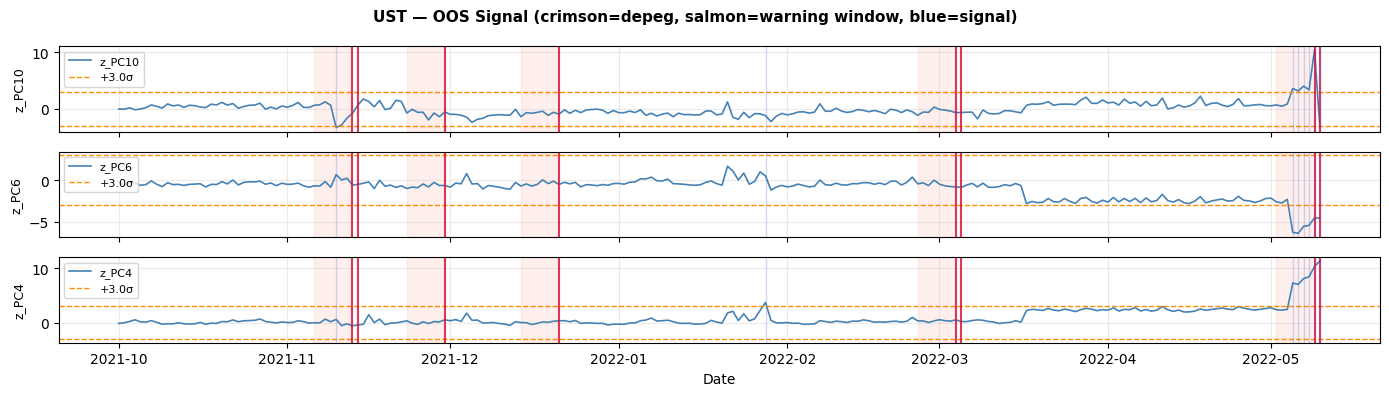

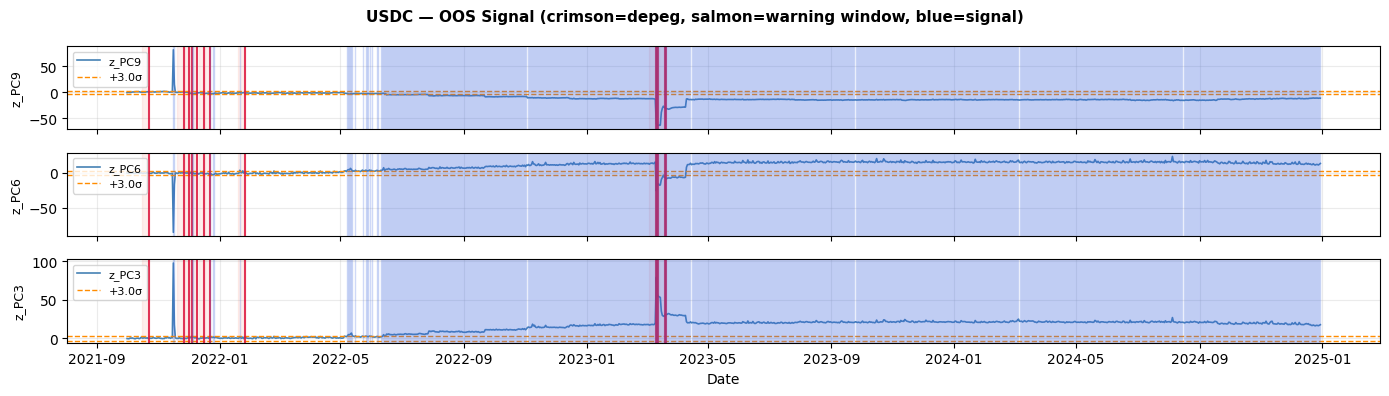

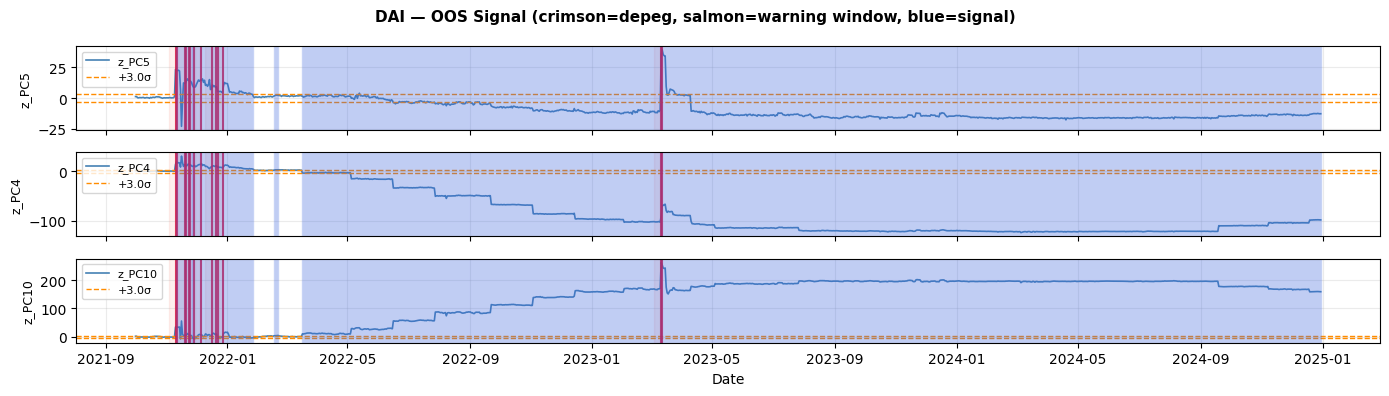

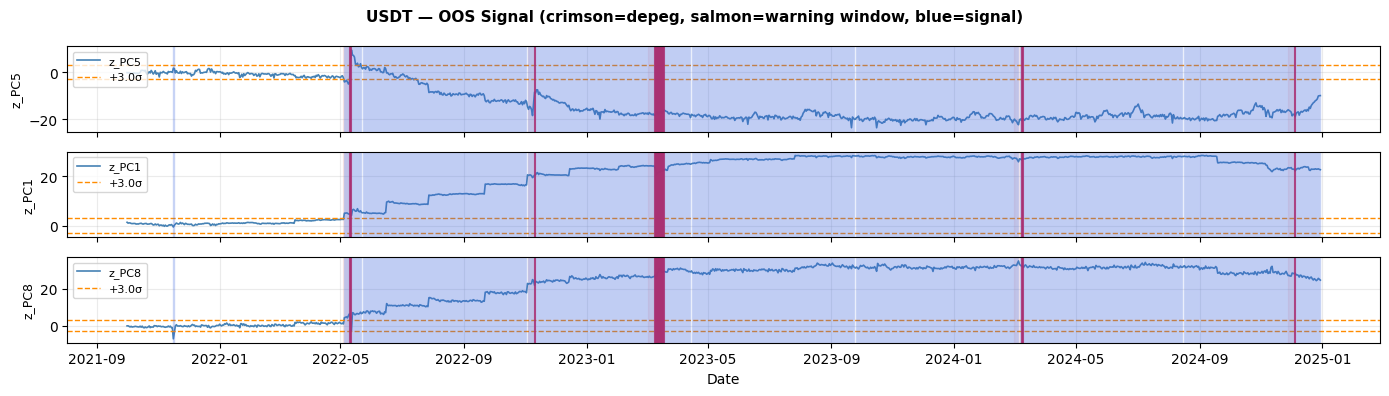

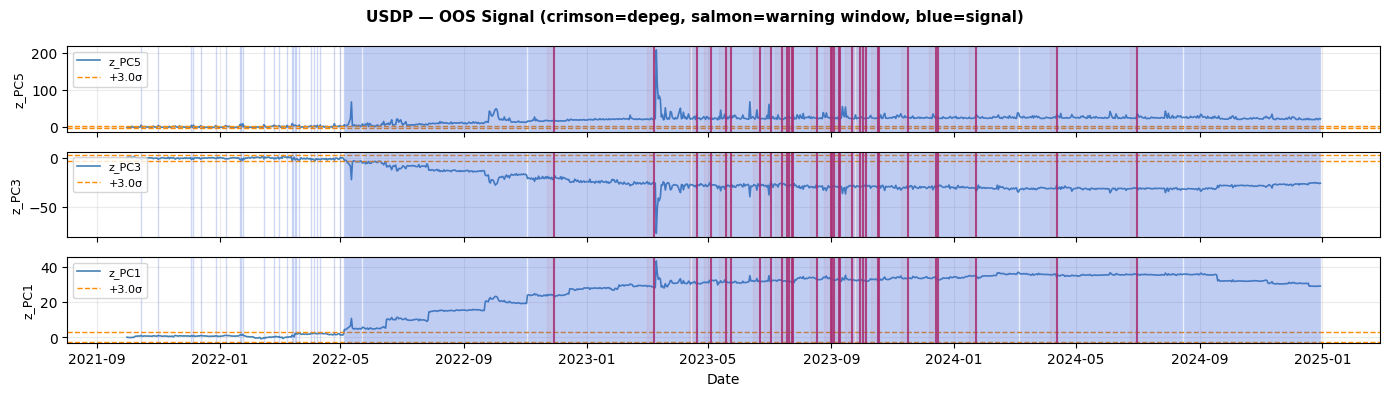

In [27]:
# plot timelines
for coin, res in results.items():
    plot_signal_timeline(
        res,
        coin=coin,
        save_path=f"stage2_pca_results/globaldate/stage2_split_globaldate_{coin}_signal.png"
    )

## PCA Loadings Analysis

In [28]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PC_SELECTIONS = {
    "UST":  [9, 5, 3], 
    "USDC": [8, 5, 2],   
    "USDP": [4, 2, 0],
    "USDT": [4, 0, 7],
    "DAI":  [4, 3, 9],
}

SPLIT_DIRS = {
    "globalsplit": "stage2_pca_results/globaldate",
}

COINS = ["UST", "USDC", "DAI", "USDT", "USDP"]

def load_saved_loadings(split_name, coin):
    path = os.path.join(SPLIT_DIRS[split_name], f"{coin}_loadings.csv")
    df = pd.read_csv(path, index_col=0)

    # if saved columns are 0,1,2... rename to PC1,PC2,...
    new_cols = []
    for c in df.columns:
        c_str = str(c)
        if c_str.isdigit():
            new_cols.append(f"PC{int(c_str)+1}")
        elif c_str.startswith("PC"):
            new_cols.append(c_str)
        else:
            new_cols.append(c_str)
    df.columns = new_cols
    return df

# extract only the selected PCs for a given split and coin
def get_selected_loadings(split_name, coin):
    df = load_saved_loadings(split_name, coin)
    selected = [f"PC{i+1}" for i in PC_SELECTIONS[coin]]
    return df[selected].copy()

###  Compare Top Loadings for One Coin Across Splits

In [29]:
def compare_coin_loadings_table(coin, top_n=12):
    dfs = []
    for split in SPLIT_DIRS:
        df = get_selected_loadings(split, coin)
        df = df.copy()
        df["max_abs_loading"] = df.abs().max(axis=1)
        df = df.sort_values("max_abs_loading", ascending=False).head(top_n)
        df["split"] = split
        df["feature"] = df.index
        dfs.append(df.reset_index(drop=True))

    out = pd.concat(dfs, ignore_index=True)
    cols = ["split", "feature"] + [f"PC{i+1}" for i in PC_SELECTIONS[coin]] + ["max_abs_loading"]
    return out[cols]

# compare loadings for the top features across splits for UST
compare = compare_coin_loadings_table("UST", top_n=25)
compare[compare["split"] == "globalsplit"].sort_values("max_abs_loading", ascending=False)

,split,feature,PC10,PC6,PC4,max_abs_loading
0,globalsplit,volume_percent_change_30d,-0.320556,-0.209997,0.546512,0.546512
1,globalsplit,volume_percent_change_7d,-0.023447,0.353289,0.446341,0.446341
2,globalsplit,downward_price_deviation_30d,-0.074537,0.422199,-0.157651,0.422199
3,globalsplit,volume_percent_change_24h,0.421713,0.279412,0.116026,0.421713
4,globalsplit,price_deviation_30d,0.090508,0.378206,-0.114958,0.378206
5,globalsplit,price_deviation_5d,0.214689,-0.372115,-0.155248,0.372115
6,globalsplit,fear_greed_index,0.341912,-0.140630,0.074385,0.341912
7,globalsplit,market_cap_percent_change_24h,0.325458,-0.060394,0.154245,0.325458
8,globalsplit,downward_price_deviation_5d,0.009726,-0.284180,-0.301950,0.301950
9,globalsplit,percent_change_24h,-0.267313,-0.084210,-0.274436,0.274436


**The loadings of the selected principal components for TerraUSD are consistently dominated by variables related to peg deviation, price instability, and supply dynamics across all splitting strategies. In particular, measures of peg error and price deviation load heavily on the first component, while circulating supply and market capitalisation changes dominate the third component, reflecting the reflexive nature of the TerraUSD mechanism. The presence of volatility and short-term return measures in higher-order components further suggests that the PCA captures transient shocks in market conditions. Together, these components represent a coherent instability structure, which explains why the PCA-based signals are informative for TerraUSD.**

### Heatmap for One Coin across Splits

/var/folders/t3/4f3r77m96393n7bqz6cbqc980000gn/T/ipykernel_87026/2069698861.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


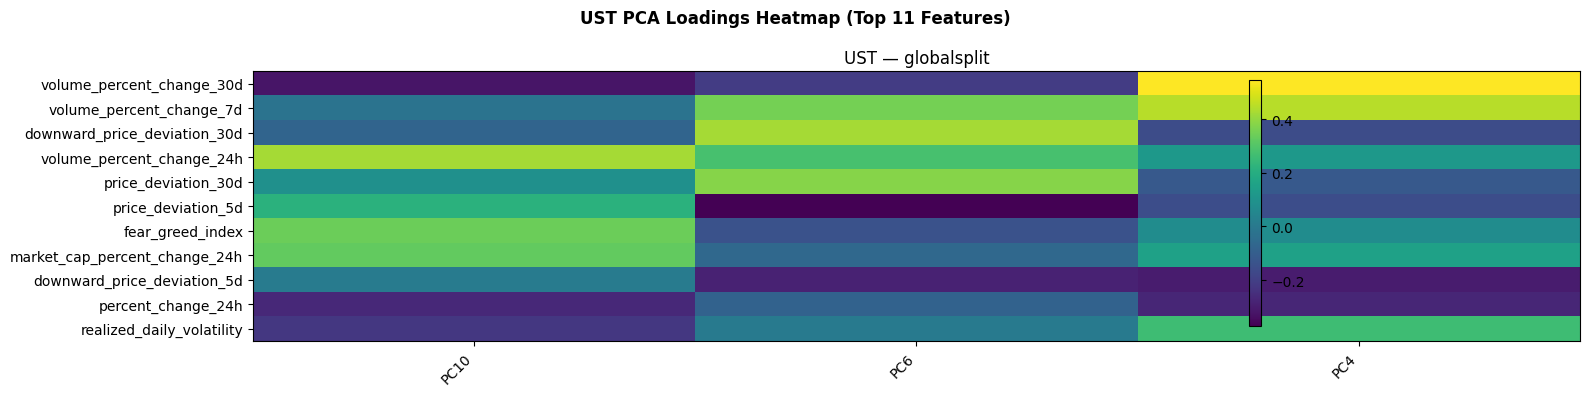

In [30]:
def plot_coin_loading_heatmaps(coin, top_n=12, figsize=(16, 4)):
    fig, axes = plt.subplots(1, len(SPLIT_DIRS), figsize=figsize, sharey=True)
    if len(SPLIT_DIRS) == 1:
        axes = [axes]

    for ax, split in zip(axes, SPLIT_DIRS):
        df = get_selected_loadings(split, coin)
        df = df.drop(index="Unnamed: 0", errors="ignore")
        df = df.copy()
        df["max_abs_loading"] = df.abs().max(axis=1)
        df = df.sort_values("max_abs_loading", ascending=False).head(top_n)
        plot_df = df.drop(columns="max_abs_loading")

        im = ax.imshow(plot_df.values, aspect="auto")
        ax.set_xticks(range(plot_df.shape[1]))
        ax.set_xticklabels(plot_df.columns, rotation=45, ha="right")
        ax.set_yticks(range(plot_df.shape[0]))
        ax.set_yticklabels(plot_df.index)
        ax.set_title(f"{coin} — {split}")
    
    fig.suptitle(f"{coin} PCA Loadings Heatmap (Top {top_n} Features)", fontsize=12, fontweight="bold")

    fig.colorbar(im, ax=axes, shrink=0.8)
    plt.tight_layout()
    plt.show()

# Example
plot_coin_loading_heatmaps("UST", top_n=11)

**The heatmap of PCA loadings across different splitting strategies shows that the economic interpretation of the selected principal components is highly consistent. Across equal-depeg, global, and custom splits, the dominant loadings remain concentrated in variables related to peg deviation, supply dynamics, and volatility. This suggests that the latent factors identified by PCA are not sensitive to the choice of training period, but instead capture stable structural dimensions of instability in TerraUSD. Such robustness provides further support for the validity of the PCA-based early warning framework.**

### Compare Selected PCs across Coins for One Split

/var/folders/t3/4f3r77m96393n7bqz6cbqc980000gn/T/ipykernel_87026/4198625027.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


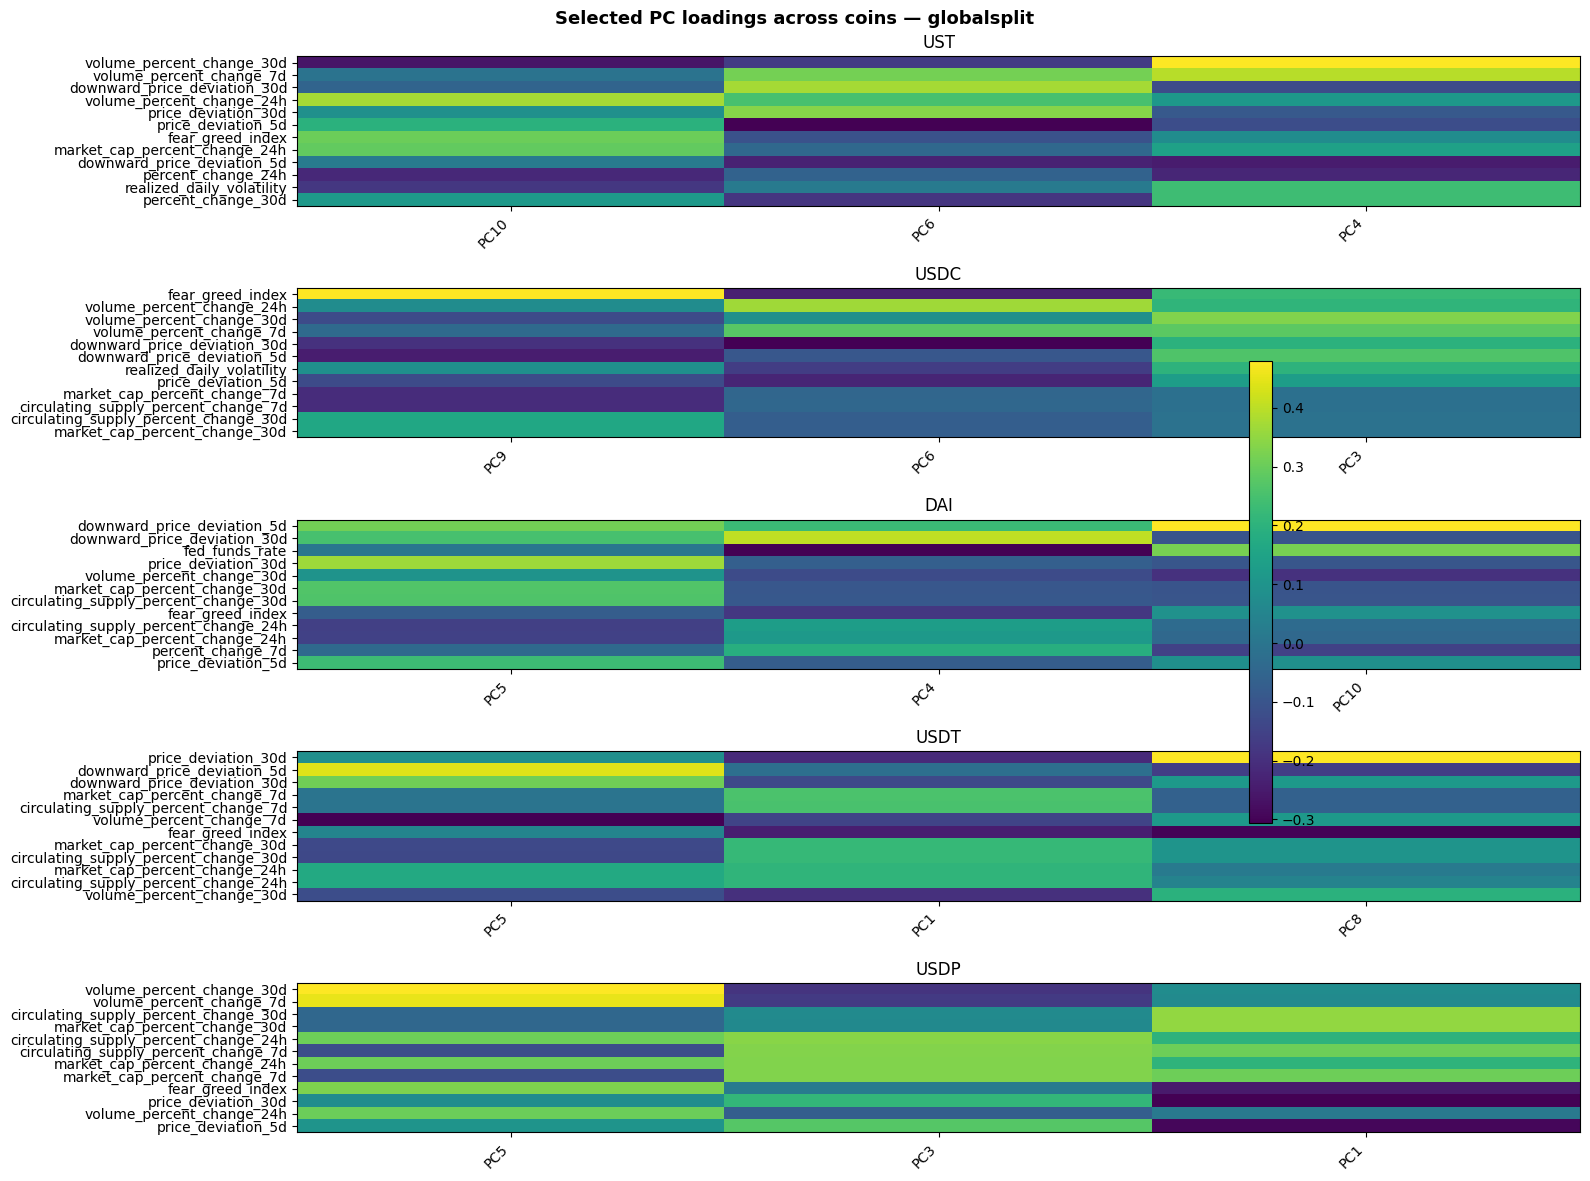

In [31]:
def plot_cross_coin_heatmaps(split_name="equaldepeg", top_n=10, figsize=(16, 12)):
    fig, axes = plt.subplots(len(COINS), 1, figsize=figsize)
    if len(COINS) == 1:
        axes = [axes]

    for ax, coin in zip(axes, COINS):
        df = get_selected_loadings(split_name, coin)
        df = df.copy()
        df["max_abs_loading"] = df.abs().max(axis=1)
        df = df.sort_values("max_abs_loading", ascending=False).head(top_n)
        plot_df = df.drop(columns="max_abs_loading")

        im = ax.imshow(plot_df.values, aspect="auto")
        ax.set_xticks(range(plot_df.shape[1]))
        ax.set_xticklabels(plot_df.columns, rotation=45, ha="right")
        ax.set_yticks(range(plot_df.shape[0]))
        ax.set_yticklabels(plot_df.index)
        ax.set_title(f"{coin}")

    fig.suptitle(f"Selected PC loadings across coins — {split_name}", fontsize=13, fontweight="bold")
    fig.colorbar(im, ax=axes, shrink=0.5)
    plt.tight_layout()
    plt.show()

# Example
plot_cross_coin_heatmaps("globalsplit", top_n=12)

When principal components are ordered by explained variance, the dominant latent factor for TerraUSD is characterised by a combination of peg deviation, price instability, and supply dynamics. In contrast, for fiat-backed stablecoins such as USDC, DAI, and USDT, the dominant components are primarily driven by market activity, liquidity, and structural supply changes. This distinction highlights that the PCA framework identifies economically meaningful instability factors only in the case of TerraUSD, where the system is inherently reflexive. For fiat-backed stablecoins, the extracted components do not align with instability dynamics, explaining the poor performance of the early warning system.

## Additional Robustness Check: Top 5 PCs
As a robustness check, we expand the signal construction to include the top five principal components ranked by explained variance, instead of the selected components identified in Stage 1. This exercise is conducted under a global split to ensure a consistent and unbiased comparison across stablecoins. The results remain qualitatively unchanged: TerraUSD continues to exhibit meaningful early warning signals, while fiat-backed stablecoins generate persistent and uninformative signals. This suggests that the findings are not driven by the specific choice of principal components, but reflect deeper structural differences in the underlying latent factors.


In [32]:
# split by global date and prepare PCA input
global_split_date = "2021-10-01"

dai_train, dai_test = split_by_date(df_dai_final, global_split_date)
dai_train_pca = prepare_stablecoin_pca_df(dai_train)
dai_test_pca = prepare_stablecoin_pca_df(dai_test)

pax_train, pax_test = split_by_date(df_pax_final, global_split_date)
pax_train_pca = prepare_stablecoin_pca_df(pax_train)
pax_test_pca = prepare_stablecoin_pca_df(pax_test)

usdc_train, usdc_test = split_by_date(df_usdc_final, global_split_date)
usdc_train_pca = prepare_stablecoin_pca_df(usdc_train)
usdc_test_pca = prepare_stablecoin_pca_df(usdc_test)

usdt_train, usdt_test = split_by_date(df_usdt_final, global_split_date)
usdt_train_pca = prepare_stablecoin_pca_df(usdt_train)
usdt_test_pca = prepare_stablecoin_pca_df(usdt_test)

ust_train, ust_test = split_by_date(df_ust_final, global_split_date)
ust_train_pca = prepare_stablecoin_pca_df(ust_train)
ust_test_pca = prepare_stablecoin_pca_df(ust_test)

Split date: 2021-10-01
Train depegs: 9, Test depegs: 14
Train size: 280, Test size: 1187
------
Split date: 2021-10-01
Train depegs: 4, Test depegs: 31
Train size: 280, Test size: 1187
------
Split date: 2021-10-01
Train depegs: 19, Test depegs: 13
Train size: 280, Test size: 1187
------
Split date: 2021-10-01
Train depegs: 10, Test depegs: 16
Train size: 280, Test size: 1187
------
Split date: 2021-10-01
Train depegs: 25, Test depegs: 8
Train size: 280, Test size: 222
------


In [33]:
# DAI
dai_pca_result = fit_fixed_pca(dai_train_pca, dai_test_pca, n_components=10)

# USDC
usdc_pca_result = fit_fixed_pca(usdc_train_pca, usdc_test_pca, n_components=10)

# UST
ust_pca_result = fit_fixed_pca(ust_train_pca, ust_test_pca, n_components=10)

# USDT
usdt_pca_result = fit_fixed_pca(usdt_train_pca, usdt_test_pca, n_components=10)

# USDP (PAX)
pax_pca_result = fit_fixed_pca(pax_train_pca, pax_test_pca, n_components=10)

In [34]:
TOP5_PCS = [0,1,2,3,4]
# reuse existing helper functions: compute_training_benchmark, compute_test_zscores, generate_signal, build_warning_labels, compute_metrics

robust_results = {}
for coin, pca_res, test_df in [
    ("UST", ust_pca_result, ust_test),
    ("USDC", usdc_pca_result, usdc_test),
    ("DAI", dai_pca_result, dai_test),
    ("USDT", usdt_pca_result, usdt_test),
    ("USDP", pax_pca_result, pax_test),
]:
    benchmark_top5 = compute_training_benchmark(pca_res, TOP5_PCS)
    z_top5 = compute_test_zscores(pca_res, benchmark_top5)
    signal_top5 = generate_signal(z_top5, threshold=3.0, consecutive_days=1)
    labeled_top5 = build_warning_labels(test_df, signal_top5, window_days=7)
    metrics_top5 = compute_metrics(labeled_top5, coin=coin)
    robust_results[coin] = {
        "benchmark": benchmark_top5,
        "z": z_top5,
        "signal": signal_top5,
        "labeled": labeled_top5,
        "metrics": metrics_top5,
    }

robust_summary = pd.DataFrame([v["metrics"] for v in robust_results.values()]).set_index("coin")
robust_summary

Training benchmark distribution:
  PC1: mean=-0.0000, sd=2.3990
  PC2: mean=-0.0000, sd=2.0574
  PC3: mean=-0.0000, sd=1.6072
  PC4: mean=0.0000, sd=1.2722
  PC5: mean=0.0000, sd=1.1699

  UST — Predictive Metrics
  Confusion: TP=5, FP=10, TN=177, FN=30
  Precision  (key): 0.333
  Recall:           0.143
  F1:               0.200
  Specificity:      0.947
  Avg lead time:    2.6 days before depeg
  False alarms:     1.37 / month
Training benchmark distribution:
  PC1: mean=-0.0000, sd=1.9748
  PC2: mean=0.0000, sd=1.9511
  PC3: mean=0.0000, sd=1.5526
  PC4: mean=-0.0000, sd=1.3671
  PC5: mean=0.0000, sd=1.2800

  USDC — Predictive Metrics
  Confusion: TP=14, FP=1010, TN=123, FN=40
  Precision  (key): 0.014
  Recall:           0.259
  F1:               0.026
  Specificity:      0.109
  Avg lead time:    3.7 days before depeg
  False alarms:     25.90 / month
Training benchmark distribution:
  PC1: mean=-0.0000, sd=2.1403
  PC2: mean=-0.0000, sd=2.0084
  PC3: mean=-0.0000, sd=1.6683
  PC

,TP,FP,TN,FN,precision,recall,f1,specificity,avg_lead_days,fa_per_month,n_test_days
coin,,,,,,,,,,,
UST,5,10,177,30,0.3333,0.1429,0.2000,0.9465,2.60,1.37,222
USDC,14,1010,123,40,0.0137,0.2593,0.0260,0.1086,3.71,25.90,1187
DAI,41,1053,86,7,0.0375,0.8542,0.0718,0.0755,3.29,27.00,1187
USDT,35,987,165,0,0.0342,1.0000,0.0662,0.1432,4.00,25.31,1187
USDP,146,892,149,0,0.1407,1.0000,0.2466,0.1431,3.69,22.87,1187


**As a robustness check, we expand the signal construction to include the top five principal components ranked by explained variance. The results show a clear deterioration in precision across all stablecoins, reflecting the introduction of noise from less relevant components. However, the qualitative findings remain unchanged. TerraUSD continues to exhibit meaningful, though weaker, early warning signals with relatively controlled false alarms. In contrast, fiat-backed stablecoins still produce persistently high false alarm rates and extremely low precision. This indicates that the effectiveness of the PCA-based framework is not driven by the specific selection of principal components, but rather by the underlying economic structure captured by the latent factors.**

## Alternative Signal Rules


In [35]:
ALT_THRESHOLD = 3.0
ALT_K = 2
ALT_PERSIST = 2

def k_of_n_signal(z_scores, threshold=ALT_THRESHOLD, k=ALT_K):
    return ((z_scores.abs() > threshold).sum(axis=1) >= k).astype(int)

def persistence_filter(signal, consecutive_days=ALT_PERSIST):
    s = signal.astype(int).reset_index(drop=True)
    if consecutive_days <= 1:
        return s
    roll = s.rolling(window=consecutive_days, min_periods=consecutive_days).sum()
    return (roll >= consecutive_days).astype(int).fillna(0)

def composite_signals(z_scores, weights=None):
    abs_z = z_scores.abs()
    if weights is None:
        return abs_z.sum(axis=1)
    return (abs_z * weights).sum(axis=1)

In [36]:
alt_results = {}

for coin, pca_res, test_df in [
    ("UST", ust_pca_result, ust_test),
    ("USDC", usdc_pca_result, usdc_test),
    ("DAI", dai_pca_result, dai_test),
    ("USDT", usdt_pca_result, usdt_test),
    ("USDP", pax_pca_result, pax_test),
]:
    # step 1: benchmark + z-scores
    benchmark = compute_training_benchmark(pca_res, PC_SELECTIONS[coin])
    z_scores = compute_test_zscores(pca_res, benchmark)

    # step 2: NEW SIGNAL
    raw_signal = k_of_n_signal(z_scores, threshold=3.0, k=2)
    signal = persistence_filter(raw_signal, consecutive_days=2)

    # step 3: evaluate
    labeled = build_warning_labels(test_df, signal, window_days=7)
    metrics = compute_metrics(labeled, coin=coin)

    alt_results[coin] = {
        "metrics": metrics,
        "signal": signal,
        "z": z_scores,
        "labeled": labeled
    }

alt_summary = pd.DataFrame(
    [v["metrics"] for v in alt_results.values()]
).set_index("coin")

alt_summary

Training benchmark distribution:
  PC10: mean=0.0000, sd=0.7314
  PC6: mean=0.0000, sd=1.0749
  PC4: mean=0.0000, sd=1.2722

  UST — Predictive Metrics
  Confusion: TP=3, FP=2, TN=185, FN=32
  Precision  (key): 0.600
  Recall:           0.086
  F1:               0.150
  Specificity:      0.989
  Avg lead time:    2.0 days before depeg
  False alarms:     0.27 / month
Training benchmark distribution:
  PC9: mean=0.0000, sd=0.8603
  PC6: mean=-0.0000, sd=1.1488
  PC3: mean=0.0000, sd=1.5526

  USDC — Predictive Metrics
  Confusion: TP=13, FP=924, TN=209, FN=41
  Precision  (key): 0.014
  Recall:           0.241
  F1:               0.026
  Specificity:      0.184
  Avg lead time:    3.8 days before depeg
  False alarms:     23.70 / month
Training benchmark distribution:
  PC5: mean=0.0000, sd=1.2400
  PC4: mean=-0.0000, sd=1.4304
  PC10: mean=-0.0000, sd=0.7100

  DAI — Predictive Metrics
  Confusion: TP=41, FP=1040, TN=99, FN=7
  Precision  (key): 0.038
  Recall:           0.854
  F1:   

,TP,FP,TN,FN,precision,recall,f1,specificity,avg_lead_days,fa_per_month,n_test_days
coin,,,,,,,,,,,
UST,3,2,185,32,0.6000,0.0857,0.1500,0.9893,2.00,0.27,222
USDC,13,924,209,41,0.0139,0.2407,0.0262,0.1845,3.77,23.70,1187
DAI,41,1040,99,7,0.0379,0.8542,0.0726,0.0869,3.29,26.67,1187
USDT,33,937,215,2,0.0340,0.9429,0.0657,0.1866,3.85,24.03,1187
USDP,146,824,217,0,0.1505,1.0000,0.2616,0.2085,3.69,21.13,1187


**Even under a stricter definition of instability requiring multi-dimensional and persistent signals, the results remain unchanged.**

To further assess the robustness of the signal definition, we impose a stricter criterion requiring at least two principal components to exceed the threshold simultaneously and persist for two consecutive periods. This significantly reduces false positives and improves precision for TerraUSD, albeit at the cost of lower recall. Importantly, the qualitative findings remain unchanged. TerraUSD continues to exhibit meaningful early warning signals, while fiat-backed stablecoins still generate persistent and uninformative signals. This indicates that instability in TerraUSD is multi-dimensional and sustained, whereas variations in other stablecoins reflect structural dynamics rather than event-specific stress.

## Event-Level Evaluation Helpers


In [37]:
EVENT_WINDOW = 7

def compute_event_table(labeled_df, warning_window_days=EVENT_WINDOW):
    df = labeled_df.sort_values("date").reset_index(drop=True)
    starts = df.loc[(df["depeg"]==1) & (df["depeg"].shift(1, fill_value=0)==0), "date"]
    rows = []
    for d in starts:
        window_start = d - pd.Timedelta(days=warning_window_days)
        prior = df[(df["date"]>=window_start) & (df["date"]<d) & (df["signal"]==1)]
        if len(prior):
            first = prior["date"].min()
            last  = prior["date"].max()
            rows.append({
                "event_date": d,
                "detected": 1,
                "first_signal": first,
                "first_lead_days": (d-first).days,
                "last_signal": last,
                "last_lead_days": (d-last).days,
            })
        else:
            rows.append({
                "event_date": d,
                "detected": 0,
                "first_signal": pd.NaT,
                "first_lead_days": pd.NA,
                "last_signal": pd.NaT,
                "last_lead_days": pd.NA,
            })
    return pd.DataFrame(rows)

def add_event_metrics(metrics, labeled_df):
    tbl = compute_event_table(labeled_df, warning_window_days=EVENT_WINDOW)
    detected = tbl["detected"].sum()
    total = len(tbl)
    metrics = metrics.copy()
    metrics.update({
        "event_hit_rate": detected/total if total else pd.NA,
        "detected_events": int(detected),
        "missed_events": int(total-detected),
        "avg_event_lead": tbl["first_lead_days"].dropna().mean() if len(tbl.dropna()) else pd.NA,
        "median_event_lead": tbl["first_lead_days"].dropna().median() if len(tbl.dropna()) else pd.NA,
    })
    return metrics, tbl


In [38]:
PEG_THR = 0.002
VOL_THR = 0.02

def run_benchmarks(test_df):
    out = {}
    if "abs_peg_error" in test_df.columns:
        peg_sig = (test_df["abs_peg_error"] > PEG_THR).astype(int)
        peg_lab = build_warning_labels(test_df, peg_sig, window_days=7)
        peg_metrics = compute_metrics(peg_lab, coin=test_df.iloc[0].get("symbol", ""))
        peg_metrics, peg_events = add_event_metrics(peg_metrics, peg_lab)
        out["peg"] = {"signal": peg_sig, "labeled": peg_lab, "metrics": peg_metrics, "events": peg_events}
    if "realized_daily_volatility" in test_df.columns:
        vol_sig = (test_df["realized_daily_volatility"] > VOL_THR).astype(int)
        vol_lab = build_warning_labels(test_df, vol_sig, window_days=7)
        vol_metrics = compute_metrics(vol_lab, coin=test_df.iloc[0].get("symbol", ""))
        vol_metrics, vol_events = add_event_metrics(vol_metrics, vol_lab)
        out["vol"] = {"signal": vol_sig, "labeled": vol_lab, "metrics": vol_metrics, "events": vol_events}
    return out


## Summary Tables (Day + Event Level)


In [39]:
summary_rows = []
for coin, res in results.items():
    m = res["metrics"].copy()
    m, _tbl = add_event_metrics(m, res["labeled_df"])
    m.update({"spec":"handpicked","signal_rule":"or"})
    summary_rows.append(m)

for coin, res in robust_results.items():
    m = res["metrics"].copy()
    m, _tbl = add_event_metrics(m, res["labeled"])
    m.update({"spec":"top5","signal_rule":"or"})
    summary_rows.append(m)

for coin, test_df in [("UST", ust_test), ("USDC", usdc_test), ("DAI", dai_test), ("USDT", usdt_test), ("USDP", pax_test)]:
    b = run_benchmarks(test_df)
    for name, obj in b.items():
        m = obj["metrics"].copy()
        m.update({"spec":"benchmark","signal_rule":name})
        summary_rows.append(m)

summary_table = pd.DataFrame(summary_rows)
#summary_table.to_csv("stage2_final_summary.csv", index=False)
summary_table



  UST — Predictive Metrics
  Confusion: TP=18, FP=80, TN=107, FN=17
  Precision  (key): 0.184
  Recall:           0.514
  F1:               0.271
  Specificity:      0.572
  Avg lead time:    3.8 days before depeg
  False alarms:     10.97 / month

  UST — Predictive Metrics
  Confusion: TP=2, FP=5, TN=182, FN=33
  Precision  (key): 0.286
  Recall:           0.057
  F1:               0.095
  Specificity:      0.973
  Avg lead time:    5.0 days before depeg
  False alarms:     0.69 / month

  USDC — Predictive Metrics
  Confusion: TP=0, FP=3, TN=1130, FN=54
  Precision  (key): 0.000
  Recall:           0.000
  F1:               nan
  Specificity:      0.997
  Avg lead time:    nan days before depeg
  False alarms:     0.08 / month

  USDC — Predictive Metrics
  Confusion: TP=0, FP=4, TN=1129, FN=54
  Precision  (key): 0.000
  Recall:           0.000
  F1:               nan
  Specificity:      0.996
  Avg lead time:    nan days before depeg
  False alarms:     0.10 / month

  DAI — Pred

,coin,TP,FP,TN,FN,precision,recall,f1,specificity,avg_lead_days,fa_per_month,n_test_days,event_hit_rate,detected_events,missed_events,avg_event_lead,median_event_lead,spec,signal_rule
0,UST,5,3,184,30,0.6250,0.1429,0.2326,0.9840,2.60,0.41,222,0.400000,2,3,3.5,3.5,handpicked,or
1,USDC,15,943,190,39,0.0157,0.2778,0.0296,0.1677,3.87,24.18,1187,0.400000,4,6,6.0,6.0,handpicked,or
2,DAI,41,1063,76,7,0.0371,0.8542,0.0712,0.0667,3.29,27.26,1187,0.900000,9,1,7.0,7.0,handpicked,or
3,USDT,34,939,213,1,0.0349,0.9714,0.0675,0.1849,3.91,24.08,1187,1.000000,5,0,6.8,7.0,handpicked,or
4,USDP,146,850,191,0,0.1466,1.0000,0.2557,0.1835,3.69,21.80,1187,1.000000,27,0,7.0,7.0,handpicked,or
5,UST,5,10,177,30,0.3333,0.1429,0.2000,0.9465,2.60,1.37,222,0.400000,2,3,3.5,3.5,top5,or
6,USDC,14,1010,123,40,0.0137,0.2593,0.0260,0.1086,3.71,25.90,1187,0.300000,3,7,5.666667,7.0,top5,or
7,DAI,41,1053,86,7,0.0375,0.8542,0.0718,0.0755,3.29,27.00,1187,0.900000,9,1,7.0,7.0,top5,or
8,USDT,35,987,165,0,0.0342,1.0000,0.0662,0.1432,4.00,25.31,1187,1.000000,5,0,7.0,7.0,top5,or
9,USDP,146,892,149,0,0.1407,1.0000,0.2466,0.1431,3.69,22.87,1187,1.000000,27,0,7.0,7.0,top5,or


**The event-level evaluation further reinforces the earlier findings. While PCA-based signals for TerraUSD exhibit moderate event detection rates, they are characterised by high precision and low false alarm rates, indicating that warnings are both meaningful and selective. In contrast, for fiat-backed stablecoins such as USDC and DAI, event detection rates are artificially high due to near-continuous signal activation, resulting in extremely low precision and rendering the signals practically useless. Benchmark models based solely on peg deviation or volatility either fail to detect events or produce excessive false alarms. These results suggest that effective early warning requires not only detecting events but doing so selectively, which is achieved only in the case of TerraUSD.**